# 5. PerturbGen gene-program discovery

This notebook analyzes the exact `masking_split/embeddings_90_10_atlas` artifact created by notebook 04. It performs no training, forecasting, or perturbation.

Leiden numbers are run-specific labels, not paper constants. A cytokine-program name must be supported by this run's genes/enrichment and must not be interpreted as causal KO validation.

This notebook analyzes embeddings produced by the **90/10 split-trained MaskGIT model** in Notebook 4:
- cell embeddings in `adata.obsm['cls_embeddings']`
- gene embeddings in `adata.varm` for `90m_LPS`, `6h_LPS`, and `10h_LPS`

The model was trained on the 90% training split, while Notebook 4 extracted embeddings over all paired cells (`split=False`). Thus this is a full-atlas descriptive analysis, not held-out benchmark evaluation.

Load the libraries

In [1]:
import scanpy as sc
import matplotlib as mpl
import numpy as np
import pandas as pd
import anndata as ad
import gseapy as gp
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text

### Config — paths for this analysis

`EMB_H5AD` = full-atlas cell + gene embeddings (notebook 4 dump, all pairings).  
`FULL_H5AD` = entire LPS paired expression object (all times; UMAP / violins).  
`GENE_NAME_ID_DICT` = Geneformer symbol↔Ensembl map (for readable gene names).


In [2]:
from pathlib import Path
import pickle
import scanpy as sc

WORKSPACE = Path("/home/stuke1/perturbgen")
SOD2 = Path("/mnt/sod2-project/csb4/stuke1/perturbgen")
LPS_DATA = Path("/mnt/sod2-project/csb4/stuke1/perturbgen_reproduction/lps")  # T_perturb moved off home

# Notebook 04 output: embeddings from the 90/10 split-trained MaskGIT model,
# extracted over all paired cells (`split=False`) for full-atlas analysis.
EMB_DIR = LPS_DATA / "res" / "masking_split" / "embeddings_90_10_atlas"
EMB_H5AD = EMB_DIR / "20260819-11:06_inference_embs_t[1, 2, 3]_scmaskgit_mpow.h5ad"

# Keep gene-program outputs beside the exact atlas used for this analysis.
RESULTS_DIR = EMB_DIR / "gene_program_discovery"
FIG_DIR = RESULTS_DIR / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# LPS expression AnnData (for optional expression UMAP / violin plots)
FULL_H5AD = (
    LPS_DATA
    / "tokenized_data"
    / "LPS_all_tps_2k"
    / "h5ad_pairing_2000_hvg_GF_genes"
    / "LPS_all_tps_2k.h5ad"
)

# Ensembl -> gene symbol (Geneformer)
GENE_NAME_ID_DICT = Path(
    "/mnt/sod2-project/csb4/stuke1/Geneformer/geneformer/gene_name_id_dict.pkl"
)

for p in (EMB_H5AD, FULL_H5AD, GENE_NAME_ID_DICT):
    assert Path(p).is_file(), f"missing: {p}"

print("EMB_DIR:", EMB_DIR)
print("EMB_H5AD:", EMB_H5AD)
print("RESULTS_DIR:", RESULTS_DIR)
print("FIG_DIR:", FIG_DIR)
print("FULL_H5AD:", FULL_H5AD)
if (EMB_DIR / "ckpt_info.txt").is_file():
    print("--- ckpt_info ---")
    print((EMB_DIR / "ckpt_info.txt").read_text())

adata = sc.read(EMB_H5AD)
print(adata)
print("obsm:", list(adata.obsm.keys()), "| varm:", list(adata.varm.keys()))
print("n_embedding_cells (unique pairing):", adata.n_obs)
assert "embeddings_90_10_atlas" in str(EMB_H5AD), EMB_H5AD
assert "benchmark_test" not in str(EMB_H5AD), "refusing test-split extract"


EMB_DIR: /mnt/sod2-project/csb4/stuke1/perturbgen_reproduction/lps/res/masking_split/embeddings_90_10_atlas
EMB_H5AD: /mnt/sod2-project/csb4/stuke1/perturbgen_reproduction/lps/res/masking_split/embeddings_90_10_atlas/20260819-11:06_inference_embs_t[1, 2, 3]_scmaskgit_mpow.h5ad
RESULTS_DIR: /mnt/sod2-project/csb4/stuke1/perturbgen_reproduction/lps/res/masking_split/embeddings_90_10_atlas/gene_program_discovery
FIG_DIR: /mnt/sod2-project/csb4/stuke1/perturbgen_reproduction/lps/res/masking_split/embeddings_90_10_atlas/gene_program_discovery/figures
FULL_H5AD: /mnt/sod2-project/csb4/stuke1/perturbgen_reproduction/lps/tokenized_data/LPS_all_tps_2k/h5ad_pairing_2000_hvg_GF_genes/LPS_all_tps_2k.h5ad
--- ckpt_info ---
ckpt=/home/stuke1/perturbgen/T_perturb/res/masking_split/checkpoints/20260818_2346_cellgen_train_masking_lr_0.0001_wd_0.0001_batch_256_ptime_pos_sin_m_pow_tp_1-2-3_s_0-epoch=49.ckpt
split_path=/home/stuke1/perturbgen/T_perturb/tokenized_data/LPS_all_tps_2k/splits/stratified_cell_

For each timepoint, the model provides gene embeddings stored in varm, while cell embeddings are available under cls_embeddings.

In [3]:
print(adata)
print("obsm keys:", list(adata.obsm.keys()))
print("varm keys:", list(adata.varm.keys()))

AnnData object with n_obs × n_vars = 69531 × 1856
    obs: 'cell_pairing_index', 'time_after_LPS', 'cell_type_harmonized', 'batch', 'cell_idx'
    var: 'token_id'
    obsm: 'cls_embeddings'
    varm: '10h_LPS', '6h_LPS', '90m_LPS'
obsm keys: ['cls_embeddings']
varm keys: ['10h_LPS', '6h_LPS', '90m_LPS']


In [4]:
# Gene embeddings by timepoint
for tp in ["90m_LPS", "6h_LPS", "10h_LPS"]:
    g = adata.varm[tp]
    print(tp, g.shape)                     # (n_genes, d_model)
    print(g[:3, :8])                       # first 3 genes, first 8 dims               # first 3 cells, first 8 dims           # first 3 cells, first 8 dims

90m_LPS (1856, 768)
[[ 0.1823983  -0.28955773 -0.43822986 -1.7701766   0.46895352 -0.44209424
  -0.07132373  0.6855164 ]
 [-0.41035676  1.6612391   0.14451465  0.10146871  0.519492    1.2144722
   1.1606499  -0.20099664]
 [-0.11210806 -0.3402698  -0.16688554 -0.6510402   1.1137966  -0.6846641
  -0.6607984   0.66487384]]
6h_LPS (1856, 768)
[[ 0.0216991  -0.11764984 -0.16537547 -2.1276357  -0.73876894 -0.37191397
   0.26575422  0.5325009 ]
 [-0.5953028   1.6856399  -0.05702832 -0.04506129  0.4956034   1.3923626
   1.1124368  -0.26457402]
 [-0.3013619  -0.5347878  -0.30182785 -0.6336351   1.089561   -0.8159997
  -0.6541629   0.5792767 ]]
10h_LPS (1856, 768)
[[-0.33572882  0.2929221  -0.23090266 -1.612408   -0.27993137 -0.68533623
   0.22099511  0.8480785 ]
 [-0.74398977  1.9274117   0.01230712  0.14066608  0.57850796  1.3506019
   1.1747288  -0.2357514 ]
 [-0.307748   -0.28681767 -0.2609571  -0.41687974  1.1457283  -0.97546804
  -0.5563764   0.641848  ]]


Optionally, cell type labels are renamed for consistency. Cell embeddings can then be used for neighborhood graph construction and UMAP visualization.

In [5]:
mapping = {
    'B cell': 'B cells',
    'CD14 monocytes': 'CD14+ monocytes',
    'CD16 monocytes': 'CD16+ monocytes',
    'CD4+ T cells': 'CD4+ T cells',
    'CD8+ T cells': 'CD8+ T cells',
    'Dendritic cells': 'Dendritic cells',
    'NK': 'NK cells',
    'NKT': 'NKT cells',
    'Plasmocytoid dendritic cell': 'Plasmacytoid dendritic cells',
    'hematopoietic stem cell': 'Hematopoietic stem cells',
    'platelet': 'Platelets'
}

adata.obs['cell_type_harmonized'] = adata.obs['cell_type_harmonized'].cat.rename_categories(
    {cat: mapping.get(cat, cat) for cat in adata.obs['cell_type_harmonized'].cat.categories}
)

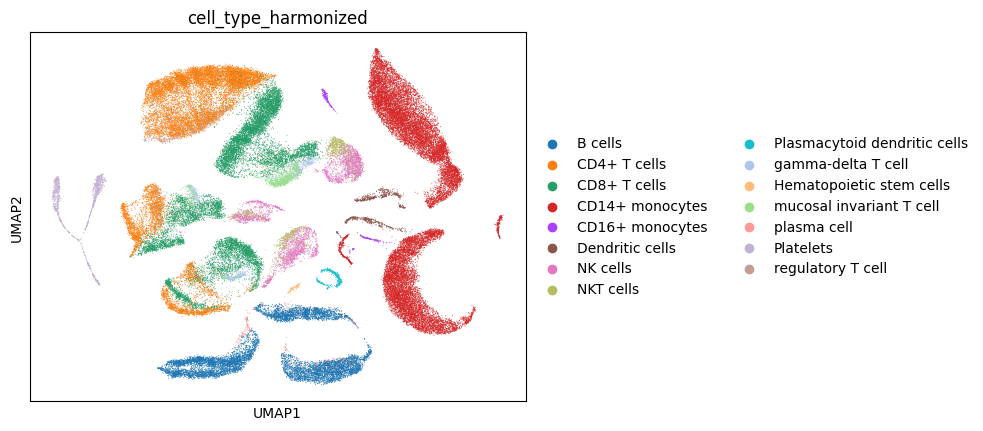

In [6]:
sc.pp.neighbors(adata,use_rep='cls_embeddings') # compute the neighborhood graph
sc.tl.umap(adata) # compute the UMAP coordinates
sc.pl.umap(adata,color='cell_type_harmonized') # plot the UMAP with cell type coloring

Load the LPS paired AnnData for (1) Ensembl→symbol mapping and (2) optional expression-space UMAP / program violin plots.


In [7]:
adata_full = sc.read(FULL_H5AD)
print(adata_full)
print("var columns:", list(adata_full.var.columns))
print("n_expression_cells (all LPS times, no split):", adata_full.n_obs)


AnnData object with n_obs × n_vars = 223478 × 1856
    obs: 'patient_id', 'time_after_LPS', 'Sex', 'age', 'batch', 'IR_VJ_1_locus_tcr', 'IR_VJ_2_locus_tcr', 'IR_VDJ_1_locus_tcr', 'IR_VDJ_2_locus_tcr', 'IR_VJ_1_cdr3_tcr', 'IR_VJ_2_cdr3_tcr', 'IR_VDJ_1_cdr3_tcr', 'IR_VDJ_2_cdr3_tcr', 'IR_VJ_1_cdr3_nt_tcr', 'IR_VJ_2_cdr3_nt_tcr', 'IR_VDJ_1_cdr3_nt_tcr', 'IR_VDJ_2_cdr3_nt_tcr', 'IR_VJ_1_expr_tcr', 'IR_VJ_2_expr_tcr', 'IR_VDJ_1_expr_tcr', 'IR_VDJ_2_expr_tcr', 'IR_VJ_1_expr_raw_tcr', 'IR_VJ_2_expr_raw_tcr', 'IR_VDJ_1_expr_raw_tcr', 'IR_VDJ_2_expr_raw_tcr', 'IR_VJ_1_v_gene_tcr', 'IR_VJ_2_v_gene_tcr', 'IR_VDJ_1_v_gene_tcr', 'IR_VDJ_2_v_gene_tcr', 'IR_VJ_1_d_gene_tcr', 'IR_VJ_2_d_gene_tcr', 'IR_VDJ_1_d_gene_tcr', 'IR_VDJ_2_d_gene_tcr', 'IR_VJ_1_j_gene_tcr', 'IR_VJ_2_j_gene_tcr', 'IR_VDJ_1_j_gene_tcr', 'IR_VDJ_2_j_gene_tcr', 'IR_VJ_1_c_gene_tcr', 'IR_VJ_2_c_gene_tcr', 'IR_VDJ_1_c_gene_tcr', 'IR_VDJ_2_c_gene_tcr', 'IR_VJ_1_junction_ins_tcr', 'IR_VJ_2_junction_ins_tcr', 'IR_VDJ_1_junction_ins_tcr'

We normalize and log-transform the original AnnData object to generate a baseline UMAP visualization. This optional step serves primarily as a comparison to the UMAP derived from PerturbGen cell embeddings.

In [8]:
sc.pp.normalize_total(adata_full) # normalize the data
sc.pp.log1p(adata_full) # log-transform the data

In [9]:
sc.pp.pca(adata_full, n_comps=768)
sc.pp.neighbors(adata_full, use_rep="X_pca")
sc.tl.umap(adata_full)

In [21]:
mapping = {
    'B cell': 'B cells',
    'CD14 monocytes': 'CD14+ monocytes',
    'CD16 monocytes': 'CD16+ monocytes',
    'CD4+ T cells': 'CD4+ T cells',
    'CD8+ T cells': 'CD8+ T cells',
    'Dendritic cells': 'Dendritic cells',
    'NK': 'NK cells',
    'NKT': 'NKT cells',
    'Plasmocytoid dendritic cell': 'Plasmacytoid dendritic cells',
    'hematopoietic stem cell': 'Hematopoietic stem cells',
    'platelet': 'Platelets'
}

adata_full.obs['cell_type_harmonized'] = adata_full.obs['cell_type_harmonized'].cat.rename_categories(
    {cat: mapping.get(cat, cat) for cat in adata_full.obs['cell_type_harmonized'].cat.categories}
)


In [22]:
sc.set_figure_params(dpi_save=600) # set high dpi for saved figures

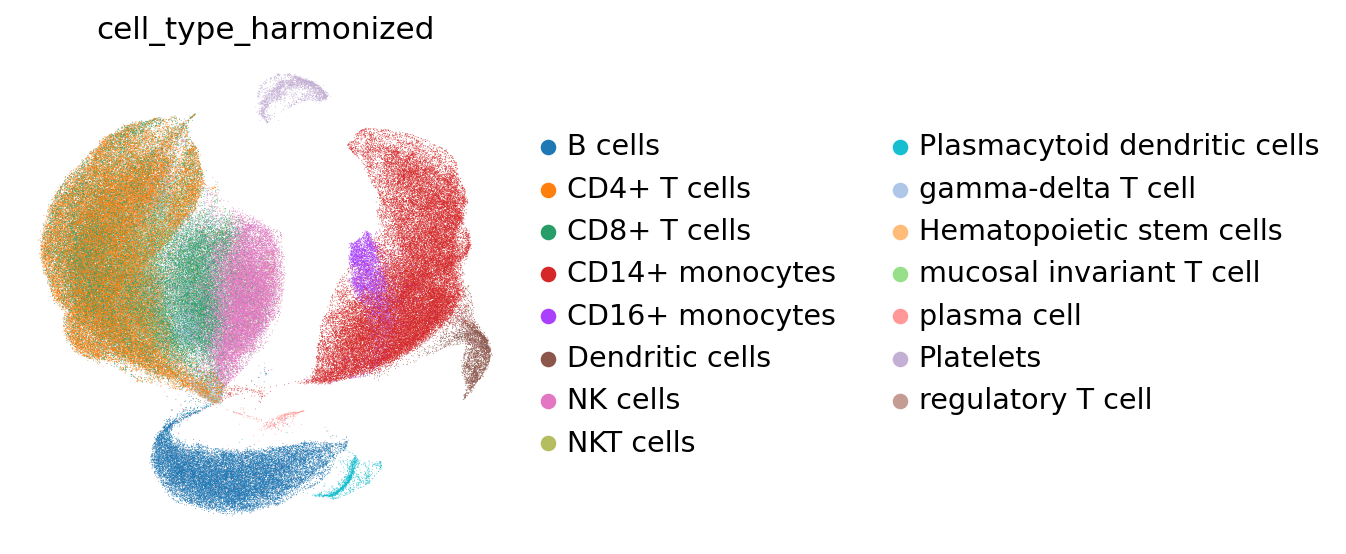

In [23]:

mpl.rcParams.update({ # set global matplotlib parameters
    "font.family": "sans-serif",
    "font.size": 18,
    "pdf.fonttype": 42, 
    "ps.fonttype": 42,
    "svg.fonttype": "none"
})

sc.pl.umap( # plot UMAP of full data
    adata_full,
    color='cell_type_harmonized',
    frameon=False,
    save='_umapcelltype.png'  
)


In [24]:
adata_full

AnnData object with n_obs × n_vars = 223478 × 1856
    obs: 'patient_id', 'time_after_LPS', 'Sex', 'age', 'batch', 'IR_VJ_1_locus_tcr', 'IR_VJ_2_locus_tcr', 'IR_VDJ_1_locus_tcr', 'IR_VDJ_2_locus_tcr', 'IR_VJ_1_cdr3_tcr', 'IR_VJ_2_cdr3_tcr', 'IR_VDJ_1_cdr3_tcr', 'IR_VDJ_2_cdr3_tcr', 'IR_VJ_1_cdr3_nt_tcr', 'IR_VJ_2_cdr3_nt_tcr', 'IR_VDJ_1_cdr3_nt_tcr', 'IR_VDJ_2_cdr3_nt_tcr', 'IR_VJ_1_expr_tcr', 'IR_VJ_2_expr_tcr', 'IR_VDJ_1_expr_tcr', 'IR_VDJ_2_expr_tcr', 'IR_VJ_1_expr_raw_tcr', 'IR_VJ_2_expr_raw_tcr', 'IR_VDJ_1_expr_raw_tcr', 'IR_VDJ_2_expr_raw_tcr', 'IR_VJ_1_v_gene_tcr', 'IR_VJ_2_v_gene_tcr', 'IR_VDJ_1_v_gene_tcr', 'IR_VDJ_2_v_gene_tcr', 'IR_VJ_1_d_gene_tcr', 'IR_VJ_2_d_gene_tcr', 'IR_VDJ_1_d_gene_tcr', 'IR_VDJ_2_d_gene_tcr', 'IR_VJ_1_j_gene_tcr', 'IR_VJ_2_j_gene_tcr', 'IR_VDJ_1_j_gene_tcr', 'IR_VDJ_2_j_gene_tcr', 'IR_VJ_1_c_gene_tcr', 'IR_VJ_2_c_gene_tcr', 'IR_VDJ_1_c_gene_tcr', 'IR_VDJ_2_c_gene_tcr', 'IR_VJ_1_junction_ins_tcr', 'IR_VJ_2_junction_ins_tcr', 'IR_VDJ_1_junction_ins_tcr'

Map Ensembl IDs in the embedding object to gene symbols via Geneformer's `gene_name_id_dict` (symbol→Ensembl), reversed.


In [25]:
with open(GENE_NAME_ID_DICT, "rb") as f:
    symbol_to_ensembl = pickle.load(f)
ensembl_to_symbol = {v: k for k, v in symbol_to_ensembl.items()}

adata.var["gene_symbol"] = [
    ensembl_to_symbol.get(g, g) for g in adata.var_names.astype(str)
]
n_sym = sum(1 for g, s in zip(adata.var_names, adata.var["gene_symbol"]) if g != s)
print(f"Mapped {n_sym}/{adata.n_vars} Ensembl IDs to gene symbols (embeddings)")

# Same mapping on expression AnnData (used later for score_genes)
if "ensembl_id" in adata_full.var.columns:
    full_ids = adata_full.var["ensembl_id"].astype(str)
elif "gene_ids-0" in adata_full.var.columns:
    full_ids = adata_full.var["gene_ids-0"].astype(str)
else:
    full_ids = pd.Index(adata_full.var_names.astype(str))
adata_full.var["gene_symbol"] = [ensembl_to_symbol.get(g, g) for g in full_ids]
n_full = sum(
    1 for g, s in zip(full_ids, adata_full.var["gene_symbol"]) if g != s
)
print(f"Mapped {n_full}/{adata_full.n_vars} Ensembl IDs to gene symbols (adata_full)")
adata.var[["gene_symbol"]].head()


Mapped 1855/1856 Ensembl IDs to gene symbols (embeddings)
Mapped 1855/1856 Ensembl IDs to gene symbols (adata_full)


,gene_symbol
ENSG00000188290,HES4
ENSG00000187608,ISG15
ENSG00000186891,TNFRSF18
ENSG00000186827,TNFRSF4
ENSG00000189409,MMP23B


We construct a new AnnData object in which each gene is treated as an observation (analogous to a cell), and its features correspond to a n(here =768)-dimensional learned embedding vector rather than expression values. This representation enables standard single-cell analysis workflows, such as UMAP visualization and clustering, to be directly applied to gene embeddings.

In [26]:
gene_symbols = adata.var['gene_symbol'].values
timepoints = list(adata.varm.keys())

all_embeddings = []
obs_names = []
obs_timepoints = []
obs_genes = []

for tp in timepoints:
    embedding = adata.varm[tp]  
    all_embeddings.append(embedding)
    
    obs_names.extend([f"{g}_{tp}" for g in gene_symbols])
    obs_genes.extend(gene_symbols)
    obs_timepoints.extend([tp] * len(gene_symbols))

X = np.vstack(all_embeddings)

obs = pd.DataFrame({
    "gene_symbol": obs_genes,
    "timepoint": obs_timepoints
}, index=obs_names)

new_adata = ad.AnnData(X=X, obs=obs)

In [27]:
new_adata

AnnData object with n_obs × n_vars = 5568 × 768
    obs: 'gene_symbol', 'timepoint'

Identify gene–timepoint vectors whose embedding values are all zero and report how many such cases exist.

In [28]:
zero_mask = (new_adata.X == 0).all(axis=1)

num_all_zero = zero_mask.sum()

print(f"Number of gene-timepoint vectors with all-zero values: {num_all_zero}")


Number of gene-timepoint vectors with all-zero values: 30


In [29]:
new_adata = new_adata[~zero_mask].copy() # Remove all-zero embeddings.

Each point below is **one gene at one LPS time**, not a cell.

The 768-d vector is the mean of that gene's decoder embedding over cells at that time, restricted to cells where the gene appeared in the token sequence. Cell types are pooled, but times are not mixed: each gene has separate 90m, 6h, and 10h vectors.

After removing all-zero vectors, the object contains approximately 5,538 gene–time points (from 1,856 genes × 3 times). Neighbors and UMAP are computed in this embedding space; drawing order is shuffled below to prevent one time point from visually covering the others.

In [30]:
sc.pp.neighbors(new_adata) # compute the neighborhood graph
sc.tl.umap(new_adata) # compute the UMAP coordinates

/home/stuke1/perturbgen/.venv/lib/python3.11/site-packages/scanpy/neighbors/__init__.py:586: UserWarning: You’re trying to run this on 768 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  X = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


/home/stuke1/perturbgen/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/stuke1/perturbgen/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


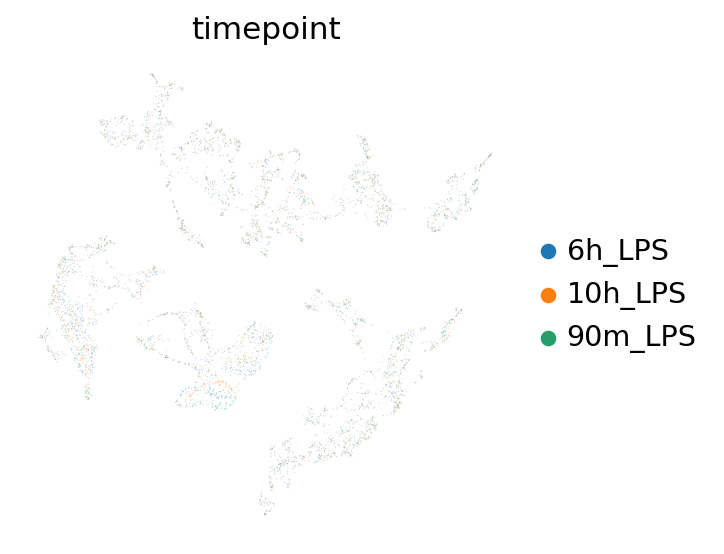

In [31]:
# Shuffle drawing order and use small transparent points so no time point
# visually covers the others when gene identity dominates time.
rng = np.random.default_rng(0)
order = rng.permutation(new_adata.n_obs)
sc.pl.umap(
    new_adata[order],
    color="timepoint",
    size=1,
    alpha=0.35,
    frameon=False,
)

Gene programs are identified by applying Leiden clustering to the gene embedding space, with each resulting cluster representing a coherent gene program.

In [30]:
sc.tl.leiden(new_adata,resolution=1,key_added='r1') # cluster gene embeddings

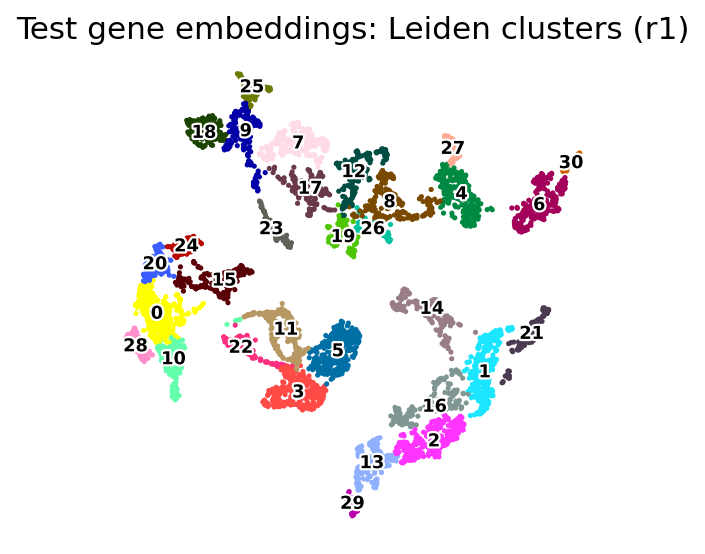

How many points in each cluster:
r1
0     334
1     329
10    208
11    207
12    203
13    201
14    192
15    174
16    169
17    161
18    147
19    139
2     322
20    135
21    129
22    103
23     96
24     87
25     84
26     72
27     72
28     68
29     51
3     294
30     42
4     292
5     289
6     264
7     248
8     218
9     208
Name: count, dtype: int64


In [31]:
# Each color = one Leiden program (r1). Numbers in the legend are cluster ids, not ranks.
sc.pl.umap(
    new_adata,
    color="r1",
    legend_loc="on data",
    legend_fontsize=8,
    legend_fontoutline=2,
    title="Test gene embeddings: Leiden clusters (r1)",
    frameon=False,
)

print("How many points in each cluster:")
print(new_adata.obs["r1"].astype(str).value_counts().sort_index())


For annotation, Leiden clusters are tested against predefined gene sets.

The next cell downloads `GO_Biological_Process_2025` and `Reactome_Pathways_2024` once, caches them under `RESULTS_DIR`, and then scores clusters locally. Gene symbols are deduplicated within each cluster, so the same gene observed at three times is submitted once; subsequent runs use the cache instead of repeating web requests.


In [32]:
# Download each Enrichr library once, then score clusters locally.
LIB_NAMES = ["GO_Biological_Process_2025", "Reactome_Pathways_2024"]
LIB_CACHE = RESULTS_DIR / "enrichr_libraries.pkl"

if LIB_CACHE.is_file():
    gene_set_dicts = pickle.loads(LIB_CACHE.read_bytes())
    print("Loaded cached Enrichr libraries:", list(gene_set_dicts))
else:
    gene_set_dicts = {}
    for name in LIB_NAMES:
        print("Downloading", name, "...")
        gene_set_dicts[name] = gp.get_library(
            name, organism="Human", min_size=5, max_size=5000
        )
    LIB_CACHE.write_bytes(pickle.dumps(gene_set_dicts))
    print("Wrote", LIB_CACHE)

clusters = sorted(
    new_adata.obs["r1"].unique(),
    key=lambda x: int(str(x)) if str(x).isdigit() else str(x),
)
results = {}
for i, cluster in enumerate(clusters, 1):
    cluster_genes = list(
        dict.fromkeys(
            new_adata.obs.loc[
                new_adata.obs["r1"] == cluster, "gene_symbol"
            ].astype(str)
        )
    )
    print(f"[{i}/{len(clusters)}] cluster {cluster}: {len(cluster_genes)} genes")
    try:
        enr = gp.enrichr(
            gene_list=cluster_genes,
            gene_sets=list(gene_set_dicts.values()),
            organism="Human",
            outdir=None,
            cutoff=0.5,
            no_plot=True,
        )
        results[cluster] = enr.results.sort_values("Adjusted P-value").head(5)
    except Exception as exc:
        print("SKIP", cluster, type(exc).__name__, exc)
        results[cluster] = pd.DataFrame()

print("clusters with terms:", sum(len(value) > 0 for value in results.values()))

Loaded cached Enrichr libraries: ['GO_Biological_Process_2025', 'Reactome_Pathways_2024']
[1/31] cluster 0: 117 genes
[2/31] cluster 1: 110 genes
[3/31] cluster 2: 108 genes
[4/31] cluster 3: 98 genes
[5/31] cluster 4: 98 genes
[6/31] cluster 5: 106 genes
[7/31] cluster 6: 88 genes
[8/31] cluster 7: 84 genes
[9/31] cluster 8: 79 genes
[10/31] cluster 9: 70 genes
[11/31] cluster 10: 72 genes
[12/31] cluster 11: 72 genes
[13/31] cluster 12: 68 genes
[14/31] cluster 13: 67 genes
[15/31] cluster 14: 66 genes
[16/31] cluster 15: 59 genes
[17/31] cluster 16: 60 genes
[18/31] cluster 17: 56 genes
[19/31] cluster 18: 49 genes
[20/31] cluster 19: 48 genes
[21/31] cluster 20: 45 genes
[22/31] cluster 21: 43 genes
[23/31] cluster 22: 42 genes
[24/31] cluster 23: 33 genes
[25/31] cluster 24: 29 genes
[26/31] cluster 25: 28 genes
[27/31] cluster 26: 26 genes
[28/31] cluster 27: 24 genes
[29/31] cluster 28: 26 genes
[30/31] cluster 29: 17 genes
[31/31] cluster 30: 14 genes
clusters with terms: 31


For this 90/10 embedding extract, cluster **19** is used as the cytokine/immune example: its enrichment includes immune-system terms, and CXCL8 (90m), IL32, and IL7R occur there. Leiden IDs are run-specific and therefore do not need to match the original tutorial's cluster 6.

In [33]:
# Force adata_full.var_names -> gene symbols (match new_adata.obs['gene_symbol']).
# NOTE: this h5ad's gene_name column is still Ensembl IDs — always map via Geneformer dict.
if "ensembl_to_symbol" not in globals():
    with open(GENE_NAME_ID_DICT, "rb") as f:
        symbol_to_ensembl = pickle.load(f)
    ensembl_to_symbol = {v: k for k, v in symbol_to_ensembl.items()}

if "ensembl_id" in adata_full.var.columns:
    ids = adata_full.var["ensembl_id"].astype(str)
elif "gene_ids-0" in adata_full.var.columns:
    ids = adata_full.var["gene_ids-0"].astype(str)
else:
    ids = pd.Index(adata_full.var_names.astype(str))

adata_full.var["ensembl_id"] = ids.values
adata_full.var["gene_symbol"] = [ensembl_to_symbol.get(g, g) for g in ids]
adata_full.var_names = adata_full.var["gene_symbol"].astype(str).values
adata_full.var_names_make_unique()

n_mapped = int((~pd.Index(adata_full.var_names).str.startswith("ENSG")).sum())
print("adata_full var_names (symbols):", list(adata_full.var_names[:5]))
print(f"Non-Ensembl var_names: {n_mapped}/{adata_full.n_vars}")
assert n_mapped > 0, "Symbol mapping failed — check GENE_NAME_ID_DICT / ensembl_to_symbol"


adata_full var_names (symbols): ['HES4', 'ISG15', 'TNFRSF18', 'TNFRSF4', 'MMP23B']
Non-Ensembl var_names: 1855/1856


In [34]:
# Validate the run-specific cytokine/immune annotation.
# In this 90/10 extract, the previously inspected candidate is Leiden cluster 19.
PROGRAM_CLUSTER = "19"
r1 = new_adata.obs["r1"].astype(str)
assert PROGRAM_CLUSTER in set(r1), f"Cluster {PROGRAM_CLUSTER} is absent in this run"

print("Genes in cluster", PROGRAM_CLUSTER, "(first 15 unique):")
print(list(new_adata.obs.loc[r1 == PROGRAM_CLUSTER, "gene_symbol"].unique()[:15]))

key = next(k for k in results if str(k) == PROGRAM_CLUSTER)
print("\nEnrichr evidence for cluster", PROGRAM_CLUSTER)
display(results[key].head(5))

highlight_genes = ["IL1RN", "IL1B", "PTX3", "IL32", "IL7R", "CXCL8", "CXCL3", "CXCL9"]
sub = new_adata.obs[
    new_adata.obs["gene_symbol"].str.upper().isin(highlight_genes)
].copy()
sub["r1"] = sub["r1"].astype(str)
print("\nWhere the declared marker panel landed (gene × time → r1):")
display(sub[["gene_symbol", "timepoint", "r1"]].sort_values(["gene_symbol", "timepoint"]))
print("Marker counts by cluster:")
print(sub["r1"].value_counts())
print("This label is an analysis annotation, not a fixed paper cluster or KO validation.")


Genes in cluster 19 (first 15 unique):
['RPS8', 'JUN', 'S100A10', 'S100A11', 'S100A9', 'S100A12', 'S100A8', 'S100A6', 'S100A4', 'RPS27', 'FCER1G', 'GNLY', 'FGFBP2', 'SPP1', 'LRBA']

Enrichr evidence for cluster 19


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
656,gs_ind_1,Immune System,23/1746,2.216575e-11,5.829592e-09,9.026749,221.448484,CST3;FCER1G;GNLY;FOS;JUN;LYZ;S100A11;VIM;CXCL8...
708,gs_ind_1,Neutrophil Degranulation,12/404,8.450129e-10,1.111192e-07,14.869479,310.648235,S100A11;S100A9;TYROBP;CST3;GSTP1;FCER1G;S100A8...
662,gs_ind_1,Innate Immune System,15/891,1.050460e-08,9.209037e-07,8.846165,162.516897,FOS;S100A11;S100A9;TYROBP;CST3;GSTP1;FCER1G;S1...
431,gs_ind_0,Regulation of Fibroblast Proliferation (GO:004...,5/46,1.887945e-07,5.324005e-05,51.568353,798.412538,S100A6;S100A9;GSTP1;CD74;FTH1
220,gs_ind_0,Neutrophil Chemotaxis (GO:0030593),5/43,1.334185e-07,5.324005e-05,55.598095,880.105354,S100A9;CXCL8;FCER1G;S100A8;S100A12



Where the declared marker panel landed (gene × time → r1):


,gene_symbol,timepoint,r1
CXCL3_6h_LPS,CXCL3,6h_LPS,17
CXCL3_10h_LPS,CXCL3,10h_LPS,17
CXCL3_90m_LPS,CXCL3,90m_LPS,17
CXCL8_6h_LPS,CXCL8,6h_LPS,12
CXCL8_10h_LPS,CXCL8,10h_LPS,12
CXCL8_90m_LPS,CXCL8,90m_LPS,19
CXCL9_6h_LPS,CXCL9,6h_LPS,8
CXCL9_10h_LPS,CXCL9,10h_LPS,8
CXCL9_90m_LPS,CXCL9,90m_LPS,8
IL1B_6h_LPS,IL1B,6h_LPS,4


Marker counts by cluster:
r1
19    7
7     3
4     3
2     3
17    3
8     3
12    2
Name: count, dtype: int64
This label is an analysis annotation, not a fixed paper cluster or KO validation.


In [35]:
# Score the selected run-specific cluster in expression space.
if "PROGRAM_CLUSTER" not in globals():
    PROGRAM_CLUSTER = "19"

genes_cluster = list(
    dict.fromkeys(
        new_adata[new_adata.obs["r1"].astype(str) == PROGRAM_CLUSTER]
        .obs["gene_symbol"]
    )
)
genes_present = [gene for gene in genes_cluster if gene in adata_full.var_names]

# Fallback if adata_full.var_names still contains Ensembl IDs.
if not genes_present:
    if "symbol_to_ensembl" not in globals():
        with open(GENE_NAME_ID_DICT, "rb") as handle:
            symbol_to_ensembl = pickle.load(handle)
    genes_present = [
        symbol_to_ensembl[gene]
        for gene in genes_cluster
        if gene in symbol_to_ensembl
        and symbol_to_ensembl[gene] in adata_full.var_names
    ]

print(
    f"Cluster {PROGRAM_CLUSTER} genes in adata_full: "
    f"{len(genes_present)}/{len(genes_cluster)}"
)
assert genes_present, "No cluster genes found; rerun the symbol-alignment cell above."
sc.tl.score_genes(
    adata_full,
    gene_list=genes_present,
    score_name="Cytokine Signaling",
)


Cluster 19 genes in adata_full: 48/48


In [36]:
if "PROGRAM_CLUSTER" not in globals():
    PROGRAM_CLUSTER = "19"

cluster_map = {PROGRAM_CLUSTER: "Cytokine Signaling"}
new_adata.obs["MoA"] = (
    new_adata.obs["r1"].astype(str).map(cluster_map).fillna("Others")
)
print("Cytokine Signaling <- Leiden", PROGRAM_CLUSTER)
print(new_adata.obs["MoA"].value_counts())

Cytokine Signaling <- Leiden 19
MoA
Others                5399
Cytokine Signaling     139
Name: count, dtype: int64


Visualize the UMAP and highlight the cluster containing the genes of interest.

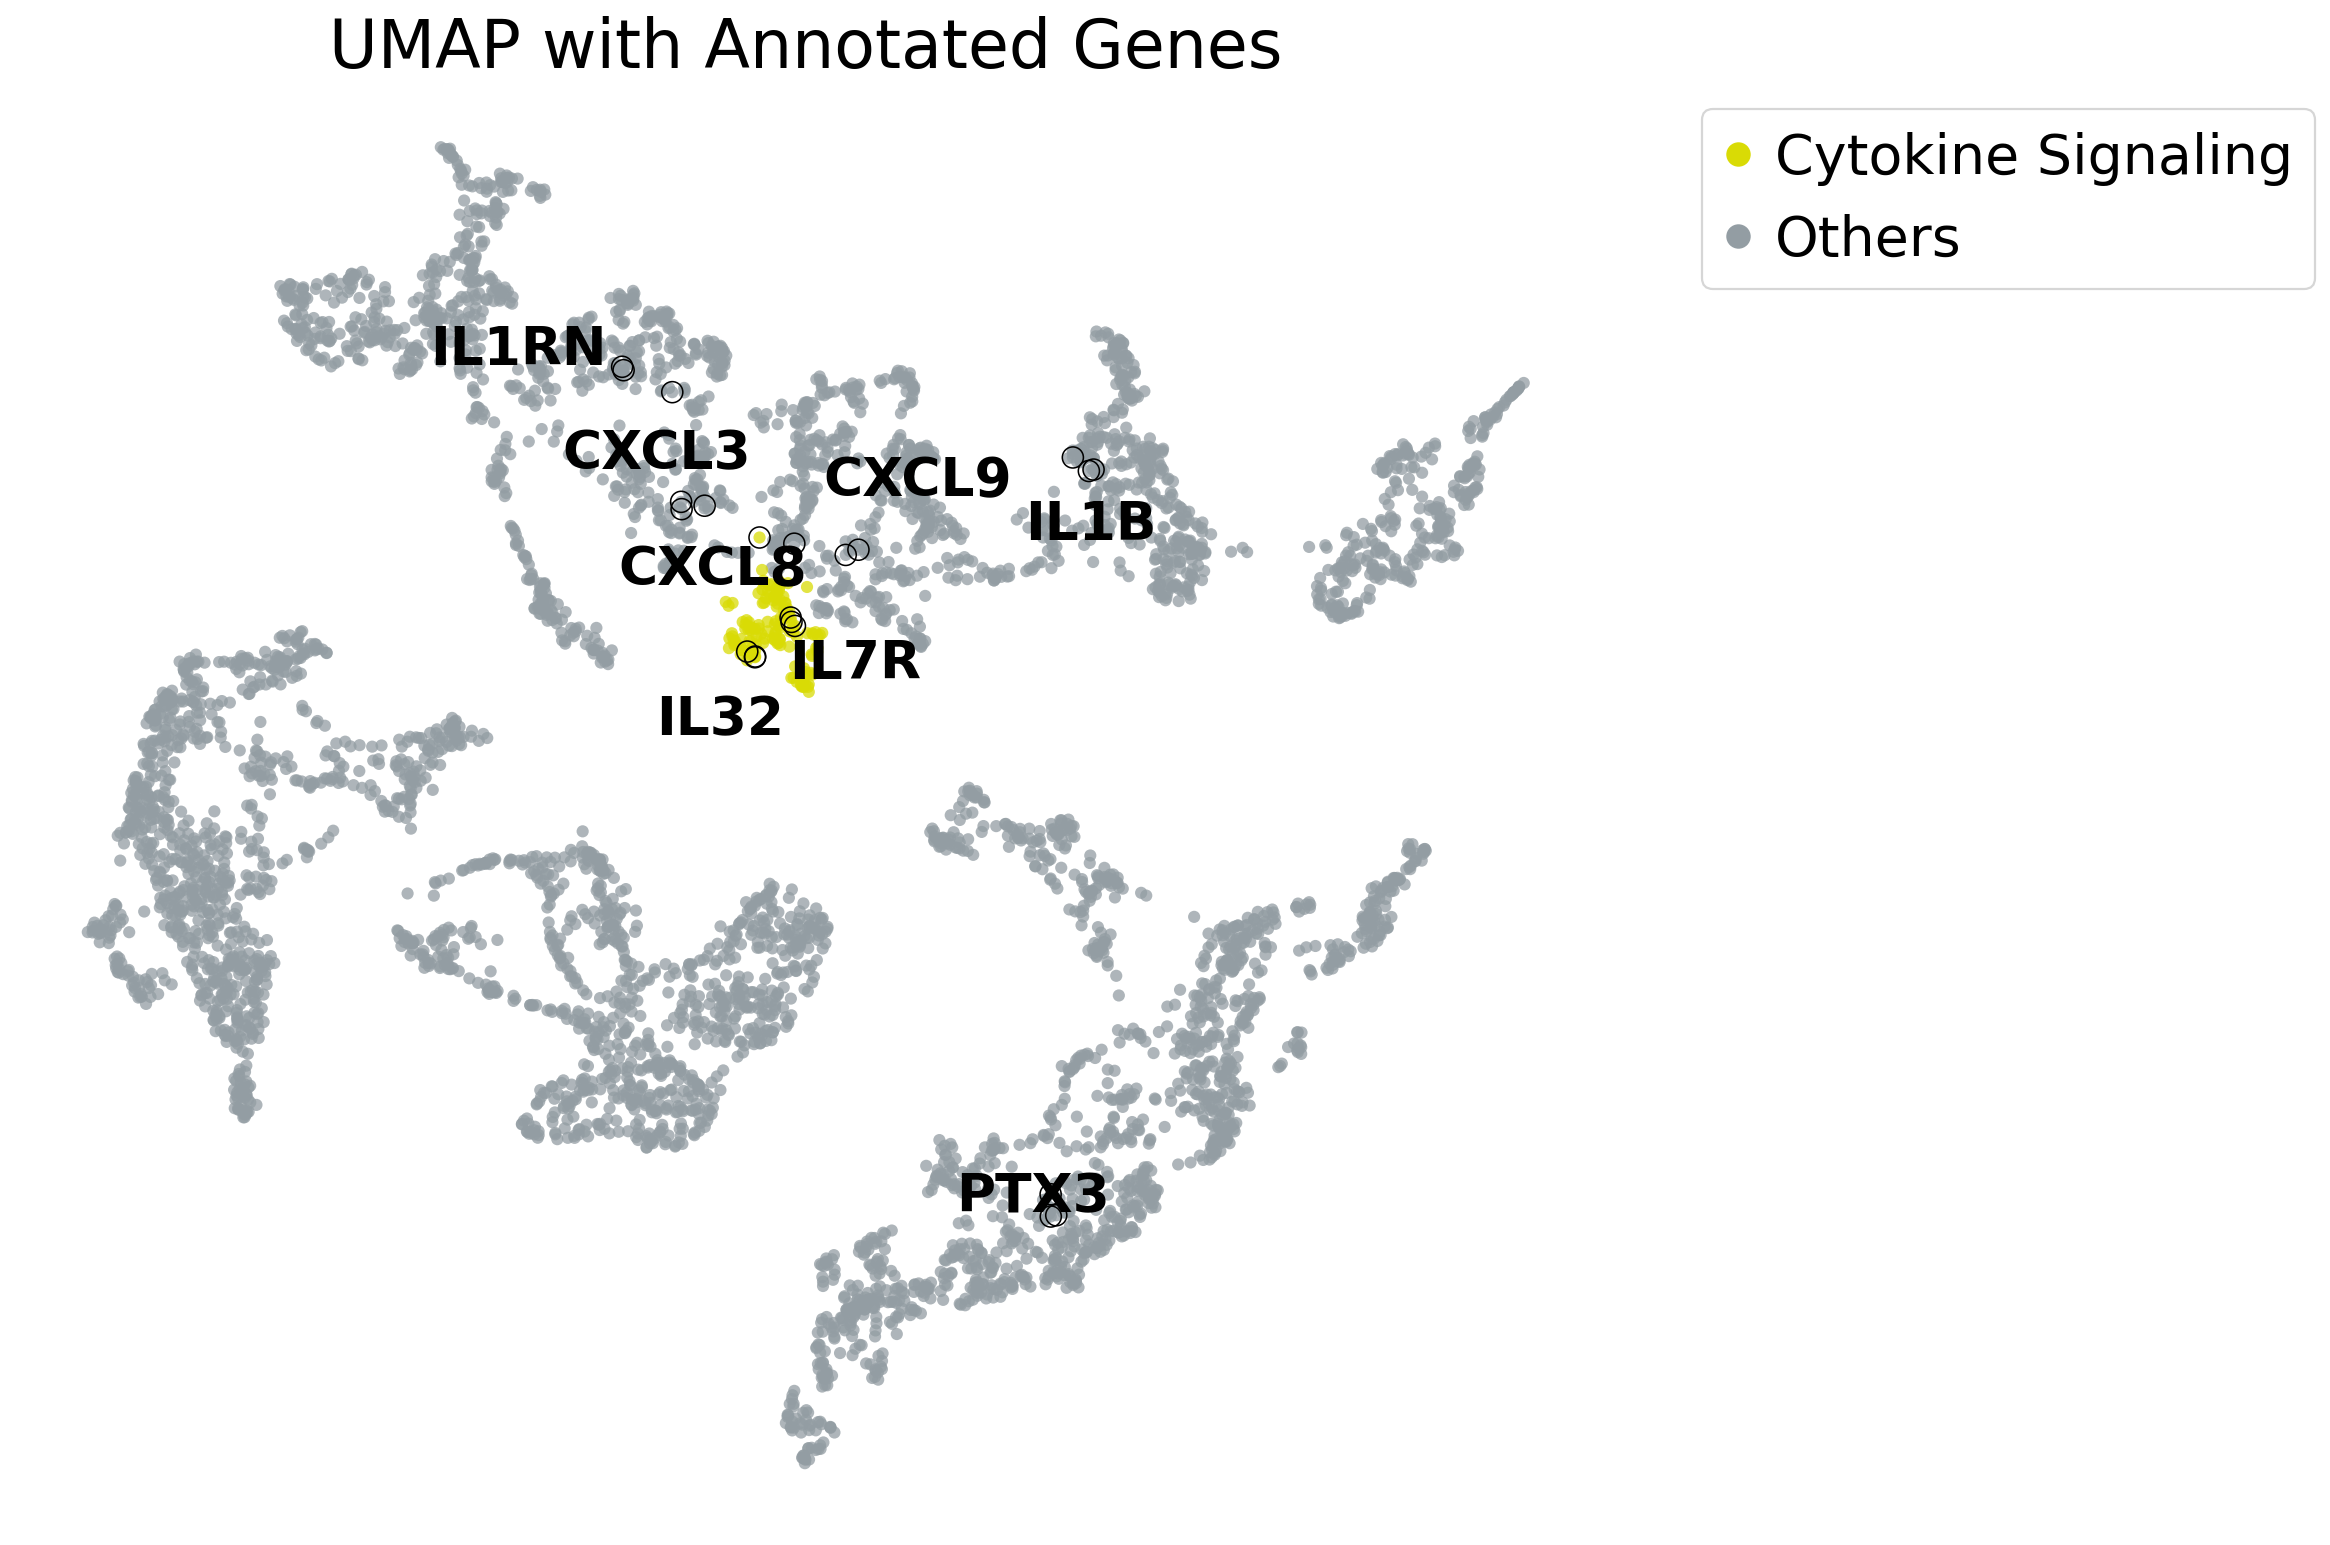

In [37]:
highlight_dict = {
    'Cytokine Signaling': ["IL1RN", "IL1B", "PTX3", "IL32", "IL7R","CXCL8","CXCL3","CXCL9"],
}
custom_colors = {
    'Cytokine Signaling': '#d9db05',
    'Others': '#939da3',
}


umap_df = pd.DataFrame(new_adata.obsm['X_umap'], columns=['UMAP1', 'UMAP2'])
umap_df['MoA']  = new_adata.obs['MoA'].astype(str).values          
umap_df['gene'] = new_adata.obs['gene_symbol'].astype(str).values  

present = sorted(umap_df['MoA'].unique())
palette = {k: custom_colors.get(k, '#939da3') for k in present}

plt.figure(figsize=(15, 10))
sns.scatterplot(
    data=umap_df, x='UMAP1', y='UMAP2', hue='MoA',
    palette=palette, linewidth=0, alpha=0.75, s=30
)
plt.title('UMAP with Annotated Genes', fontsize=30)
plt.xlabel('UMAP1', fontsize=24); plt.ylabel('UMAP2', fontsize=24)
plt.axis('off'); plt.grid(False)

texts = []
for moa, genes in highlight_dict.items():
    for gene in genes:
        mask = (umap_df['gene'].str.upper() == gene.upper()) & (umap_df['MoA'] == moa)
        if not mask.any():
            mask = (umap_df['gene'].str.upper() == gene.upper())

        if mask.any():
            plt.scatter(
                umap_df.loc[mask, 'UMAP1'],
                umap_df.loc[mask, 'UMAP2'],
                s=90, linewidths=0.7, edgecolors='k', facecolors='none', zorder=5
            )

            x_med = umap_df.loc[mask, 'UMAP1'].median()
            y_med = umap_df.loc[mask, 'UMAP2'].median()
            jitter_x = x_med - 1.0 if gene == "IL1RN" else x_med + np.random.uniform(-0.5, 0.5)
            jitter_y = y_med + np.random.uniform(-0.5, 0.5)

            texts.append(
                plt.text(jitter_x, jitter_y, gene,
                         fontsize=24, fontweight='bold', ha='center', va='center', zorder=6)
            )

adjust_text(
    texts,
    expand_points=(15, 15),
    expand_text=(10, 10),
    force_points=5.0,
    force_text=5.0,
    pad=10.0,
    only_move={'points': 'xy', 'text': 'xy'},
    autoalign='xy',
    lim=1500
)

handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=palette[k], markersize=12) for k in present]
plt.legend(handles=handles, labels=present, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=25)

plt.tight_layout()
plt.savefig(FIG_DIR / "umap_highlight_gene_symbol.png", dpi=600, bbox_inches="tight")
plt.show()


Optionally, you may visualize the z-score expression of a gene program of interest, stratified by cell type or another relevant variable.

/tmp/ipykernel_1970327/2005851278.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('cell_type_harmonized')['Cytokine Signaling']
/tmp/ipykernel_1970327/2005851278.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


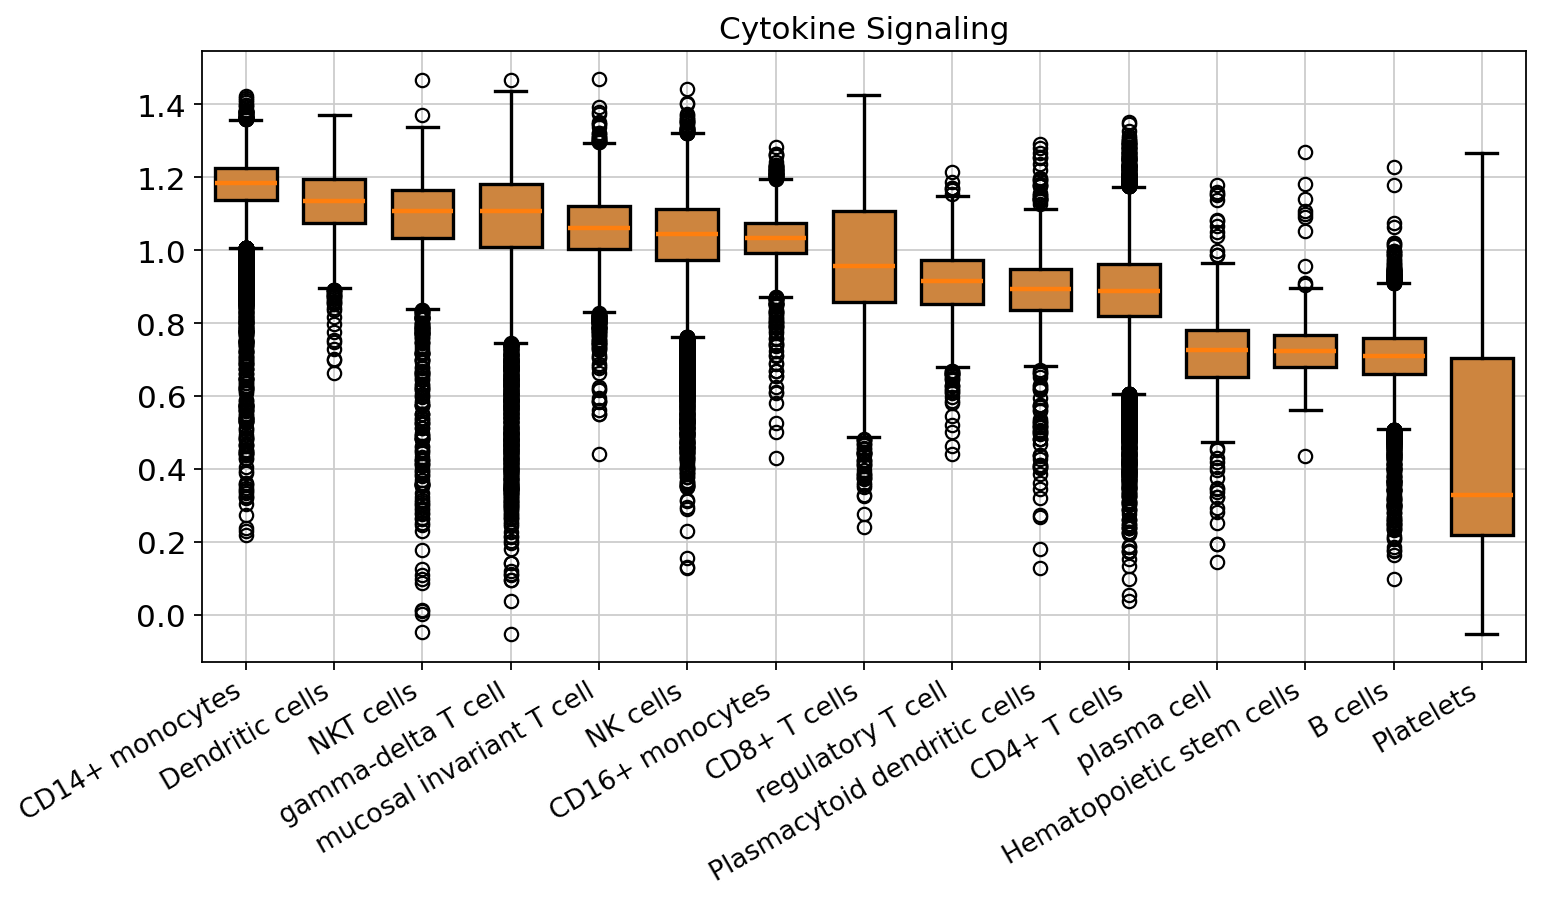

In [38]:
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 18,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none"
})


df = adata_full.obs[['cell_type_harmonized', 'Cytokine Signaling']].dropna()

ordered_cell_types = (
    df.groupby('cell_type_harmonized')['Cytokine Signaling']
      .median()
      .sort_values(ascending=False)
      .index.tolist()
)

data = [df.loc[df['cell_type_harmonized'] == ct, 'Cytokine Signaling'].values
        for ct in ordered_cell_types]

fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot(
    data,
    patch_artist=True,  
    labels=ordered_cell_types,
    widths=0.7,
    medianprops=dict(linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    boxprops=dict(linewidth=1.5)
)

for box in bp['boxes']:
    box.set_facecolor('peru')

ax.set_title('Cytokine Signaling')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / "cytokine_signaling_boxplot.pdf", dpi=600, bbox_inches="tight", format="pdf")
plt.show()


We subset the data to the myeloid lineage, as the gene program was highly enriched in these cells. We then examined the gene program scores within the myeloid population across different timepoints.

In [39]:
myeloids = adata_full[adata_full.obs['cell_type_harmonized'].isin(['CD14+ monocytes','CD16+ monocytes','Dendritic cells'])].copy()

In [40]:
s = myeloids.obs['time_after_LPS'].astype('category')

rename_map = {
    '90m_LPS': '90m',
    '6h_LPS':  '6h',
    '10h_LPS': '10h',
    'normal':  'normal',
}
s = s.cat.rename_categories({k: v for k, v in rename_map.items() if k in s.cat.categories})

new_order = ['normal', '90m', '6h', '10h']
s = s.cat.reorder_categories(new_order, ordered=True)

myeloids.obs['time_after_LPS'] = s

palette = {
    'normal': '#d62728',
    '90m':    '#2ca02c',
    '6h':     '#1f77b4',
    '10h':    '#ff7f0e',
}
myeloids.uns['time_after_LPS_colors'] = [palette[c] for c in s.cat.categories]

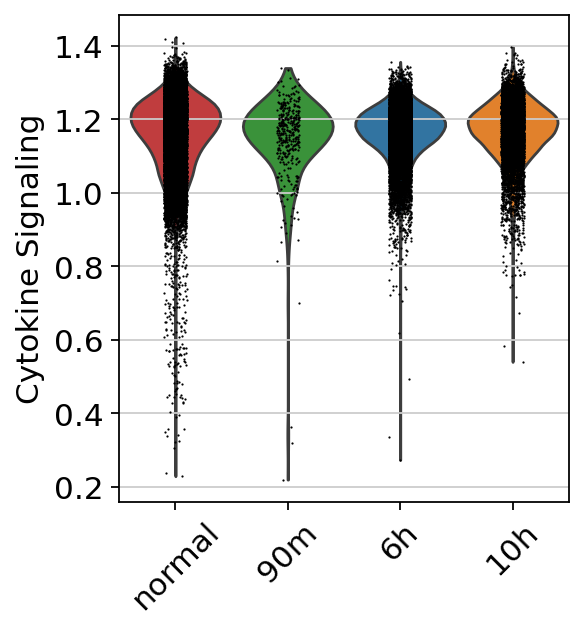

In [41]:
sc.pl.violin(myeloids,keys='Cytokine Signaling',groupby='time_after_LPS',rotation=45,save='myeloids.png') # plot violin plot of Cytokine Signaling score in myeloid cells